In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [37]:
df = pd.read_csv("titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [38]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [39]:
age_serie = df["age"]
print(type(age_serie))
print(age_serie.head)

<class 'pandas.Series'>
<bound method NDFrame.head of 0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: age, Length: 891, dtype: float64>


# Il faudra faire attention aux valeurs manquantes

In [40]:
df["age"] # série
df[["age"]] # colonne

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [41]:
survivant = df[df["survived"] == 1]
survivant

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875,1,3,female,15.0,0,0,7.2250,C,Third,child,False,NaN,Cherbourg,yes,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
880,1,2,female,25.0,0,1,26.0000,S,Second,woman,False,NaN,Southampton,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


# Traitement des valeurs manquantes

In [42]:
# Remplir les valeurs manquantes
print("Traitement des valeurs manquantes...")
print("\n" + "="*70)

# Créer une copie pour le traitement
df_clean = df.copy()

# Variables numériques - Remplir avec la médiane
numeric_columns = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

print("\n📊 VARIABLES NUMÉRIQUES (remplies avec la médiane):")
print("-" * 70)
for col in numeric_columns:
    missing_count = df_clean[col].isnull().sum()
    if missing_count > 0:
        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)
        print(f"✓ {col}: {missing_count} valeurs manquantes → remplies avec médiane = {median_value:.2f}")
    else:
        print(f"✓ {col}: Aucune valeur manquante")

# Variables catégorielles - Remplir avec des valeurs aléatoires parmi les existantes
categorical_columns = ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

print("\n📋 VARIABLES CATÉGORIELLES (remplies avec échantillonnage aléatoire):")
print("-" * 70)
for col in categorical_columns:
    missing_count = df_clean[col].isnull().sum()
    if missing_count > 0:
        # Échantillonner aléatoirement parmi les valeurs existantes
        random_sample = df_clean[col].dropna().sample(n=missing_count, replace=True, random_state=42)
        df_clean.loc[df_clean[col].isnull(), col] = random_sample.values
        print(f"✓ {col}: {missing_count} valeurs manquantes → remplies aléatoirement")
    else:
        print(f"✓ {col}: Aucune valeur manquante")

Traitement des valeurs manquantes...


📊 VARIABLES NUMÉRIQUES (remplies avec la médiane):
----------------------------------------------------------------------
✓ survived: Aucune valeur manquante
✓ pclass: Aucune valeur manquante
✓ age: 177 valeurs manquantes → remplies avec médiane = 28.00
✓ sibsp: Aucune valeur manquante
✓ parch: Aucune valeur manquante
✓ fare: Aucune valeur manquante

📋 VARIABLES CATÉGORIELLES (remplies avec échantillonnage aléatoire):
----------------------------------------------------------------------
✓ sex: Aucune valeur manquante
✓ embarked: 2 valeurs manquantes → remplies aléatoirement
✓ class: Aucune valeur manquante
✓ who: Aucune valeur manquante
✓ adult_male: Aucune valeur manquante
✓ deck: 688 valeurs manquantes → remplies aléatoirement
✓ embark_town: 2 valeurs manquantes → remplies aléatoirement
✓ alive: Aucune valeur manquante
✓ alone: Aucune valeur manquante


# Utilisation des données nettoyées pour les analyses

## Matrice de corrélation globale

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')


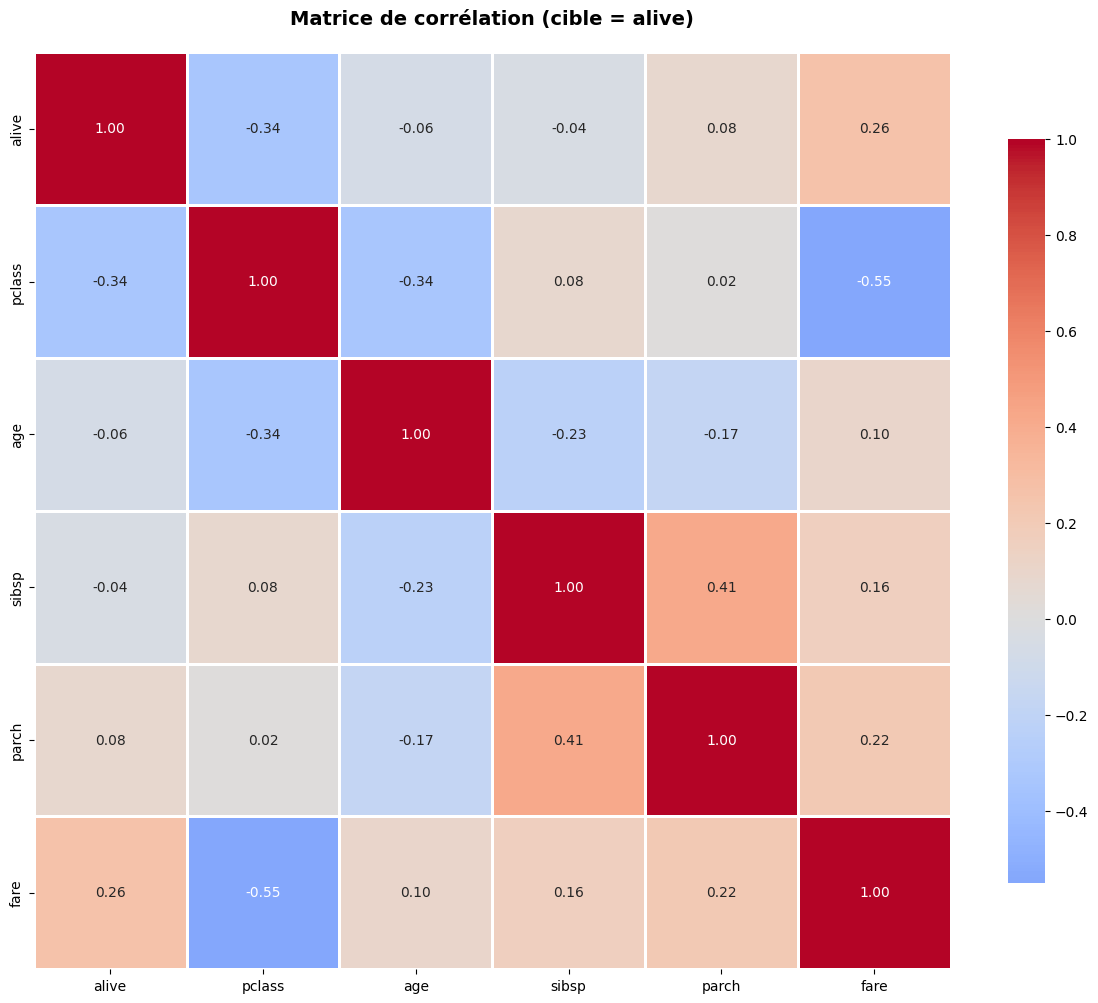

Corrélations avec alive (triées par valeur absolue):
pclass    0.338481
fare      0.257307
parch     0.081629
age       0.064910
sibsp     0.035322
Name: alive, dtype: float64


In [45]:
print(df_clean.columns)
target = 'alive' if 'alive' in df_clean.columns else 'survived'

numeric_cols = [target, 'pclass', 'age', 'sibsp', 'parch', 'fare']
df_corr = df_clean[numeric_cols].copy()

# Convertir la cible en numérique (True/False ou 'yes'/'no' -> 1/0)
df_corr[target] = df_corr[target].map({True:1, False:0, 'yes':1, 'no':0}).astype(int)

# Calculer la matrice de corrélation
correlation_matrix = df_corr.corr()

# Visualiser avec une heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title(f'Matrice de corrélation (cible = {target})', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f'Corrélations avec {target} (triées par valeur absolue):')
print(correlation_matrix[target].drop(target).abs().sort_values(ascending=False))